<a href="https://colab.research.google.com/github/MBKNgcobo/GF.github.io/blob/main/fashion_mnist_task_improved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Improved Fashion MNIST Task

**What this notebook adds:** reproducibility, clear sections (setup, data, model, training, evaluation), modular helper functions, callbacks (EarlyStopping & ModelCheckpoint), metric plotting, and saving the final model.

## 1 — Install & imports
This cell contains only imports and a helper to check the runtime (CPU/GPU). Run this first.

In [ ]:
# Basic setup & imports
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Check Python environment & devices (GPU if available)
try:
    import tensorflow as tf
    print('TensorFlow version:', tf.__version__)
    gpus = tf.config.list_physical_devices('GPU')
    print('GPUs found:', len(gpus))
except Exception as e:
    print('TensorFlow not available:', e)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)


TensorFlow version: 2.19.0
GPUs found: 0


## 2 — Hyperparameters
Centralize your configurable hyperparameters here so experiments are easy to reproduce.

In [ ]:
# Hyperparameters
BATCH_SIZE = 128
EPOCHS = 30
LEARNING_RATE = 1e-3
VALIDATION_SPLIT = 0.1
MODEL_DIR = Path('models')
MODEL_DIR.mkdir(exist_ok=True)


## 3 — Load & preprocess data
Load Fashion MNIST from Keras, normalize, and optionally add augmentation.

In [ ]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

# Load dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize and reshape for a CNN (channels-last)
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0
x_train = np.expand_dims(x_train, -1)  # shape: (N, 28, 28, 1)
x_test  = np.expand_dims(x_test, -1)

# Convert labels to categorical if using categorical_crossentropy
NUM_CLASSES = 10
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat  = to_categorical(y_test, NUM_CLASSES)

print('x_train shape:', x_train.shape, 'y_train shape:', y_train.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28, 1) y_train shape: (60000,)


## 4 — Quick visualize
Always inspect a few examples to make sure data looks correct.

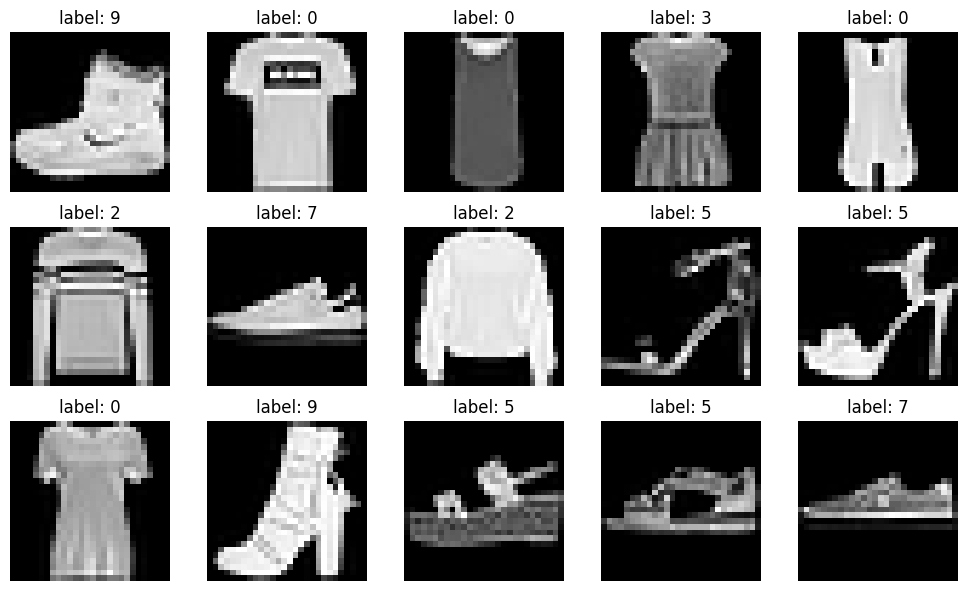

In [ ]:
# Visualize a small grid of samples
fig, axes = plt.subplots(3, 5, figsize=(10,6))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i].squeeze(), cmap='gray')
    ax.set_title(f'label: {y_train[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()


## 5 — Build the model (clean, modular)
Define a function that returns a compiled model so hyperparameter search is easy.

In [ ]:
from tensorflow.keras import layers, models, optimizers, callbacks

def build_cnn(input_shape=(28,28,1), num_classes=10, learning_rate=1e-3):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPool2D(),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPool2D(),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    opt = optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Instantiate and show summary
model = build_cnn(input_shape=x_train.shape[1:], num_classes=NUM_CLASSES, learning_rate=LEARNING_RATE)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,474 (400.29 KB)

 Trainable params: 102,026 (398.54 KB)

 Non-trainable params: 448 (1.75 KB)

## 6 — Callbacks
Add EarlyStopping and ModelCheckpoint to save the best weights.

In [ ]:
checkpoint_path = MODEL_DIR / 'best_model.h5'
cb_early = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
cb_chkpt = callbacks.ModelCheckpoint(str(checkpoint_path), monitor='val_loss', save_best_only=True)
cb_list = [cb_early, cb_chkpt]
print('Callbacks ready, checkpoint:', checkpoint_path)


Callbacks ready, checkpoint: models/best_model.h5


## 7 — Train
Train the model. Keep training cell simple and log training history to a variable for plotting later.

In [ ]:
history = model.fit(
    x_train, y_train_cat,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VALIDATION_SPLIT,
    callbacks=cb_list,
    verbose=2
)


Epoch 1/30


422/422 - 110s - 261ms/step - accuracy: 0.8112 - loss: 0.5382 - val_accuracy: 0.1352 - val_loss: 4.4936
Epoch 2/30


422/422 - 106s - 251ms/step - accuracy: 0.8872 - loss: 0.3159 - val_accuracy: 0.8698 - val_loss: 0.3634
Epoch 3/30


422/422 - 108s - 255ms/step - accuracy: 0.9020 - loss: 0.2720 - val_accuracy: 0.8962 - val_loss: 0.2834
Epoch 4/30


422/422 - 107s - 253ms/step - accuracy: 0.9101 - loss: 0.2467 - val_accuracy: 0.8998 - val_loss: 0.2714
Epoch 5/30
422/422 - 145s - 345ms/step - accuracy: 0.9183 - loss: 0.2293 - val_accuracy: 0.8973 - val_loss: 0.2838
Epoch 6/30


422/422 - 109s - 258ms/step - accuracy: 0.9216 - loss: 0.2194 - val_accuracy: 0.9035 - val_loss: 0.2606
Epoch 7/30


422/422 - 109s - 258ms/step - accuracy: 0.9250 - loss: 0.2053 - val_accuracy: 0.9107 - val_loss: 0.2469
Epoch 8/30


422/422 - 144s - 340ms/step - accuracy: 0.9293 - loss: 0.1940 - val_accuracy: 0.9128 - val_loss: 0.2397
Epoch 9/30


422/422 - 109s - 259ms/step - accuracy: 0.9321 - loss: 0.1872 - val_accuracy: 0.9205 - val_loss: 0.2192
Epoch 10/30
422/422 - 141s - 335ms/step - accuracy: 0.9352 - loss: 0.1776 - val_accuracy: 0.9145 - val_loss: 0.2457
Epoch 11/30
422/422 - 112s - 266ms/step - accuracy: 0.9365 - loss: 0.1712 - val_accuracy: 0.8905 - val_loss: 0.3073
Epoch 12/30
422/422 - 144s - 340ms/step - accuracy: 0.9418 - loss: 0.1604 - val_accuracy: 0.8813 - val_loss: 0.3164
Epoch 13/30
422/422 - 141s - 335ms/step - accuracy: 0.9423 - loss: 0.1552 - val_accuracy: 0.9188 - val_loss: 0.2245
Epoch 14/30
422/422 - 142s - 337ms/step - accuracy: 0.9441 - loss: 0.1523 - val_accuracy: 0.8960 - val_loss: 0.3135


## 8 — Plot training curves
Plot loss & accuracy for train/val to check for overfitting.

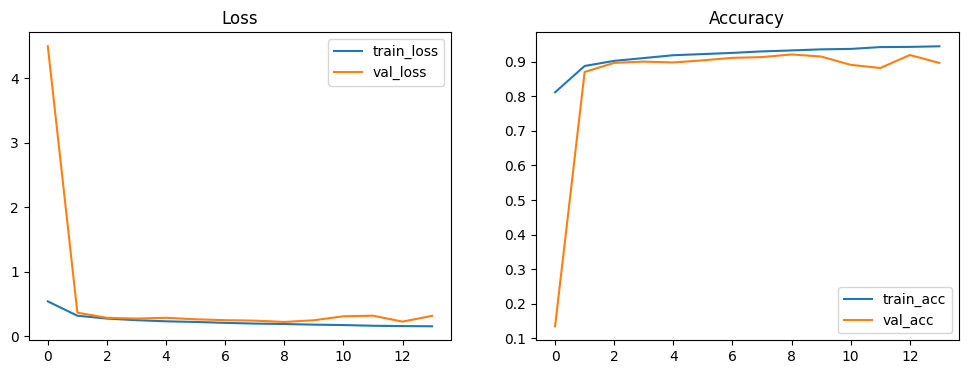

In [ ]:
def plot_history(h):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(h.history['loss'], label='train_loss')
    plt.plot(h.history['val_loss'], label='val_loss')
    plt.legend(); plt.title('Loss')

    plt.subplot(1,2,2)
    plt.plot(h.history['accuracy'], label='train_acc')
    plt.plot(h.history['val_accuracy'], label='val_acc')
    plt.legend(); plt.title('Accuracy')
    plt.show()

plot_history(history)


## 9 — Evaluate on test set and show detailed metrics
Use sklearn for classification report & confusion matrix.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f'Test loss: {test_loss:.4f}  Test accuracy: {test_acc:.4f}')

# Predictions and report
y_pred = model.predict(x_test).argmax(axis=1)
print(classification_report(y_test, y_pred))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()


## 10 — Save final model & notes
Explain how to load the saved model later.

In [ ]:
# Save final model (architecture + weights)
final_path = MODEL_DIR / 'final_model.h5'
model.save(final_path)
print('Saved final model to', final_path)


## Appendix: Tips & experiments
- Try data augmentation with ImageDataGenerator or tf.data pipeline.
- Try deeper models or transfer learning (convert images to 3-channels and use a small pretrained CNN).
- Run multiple seeds and log experiments with Weights & Biases or TensorBoard.
